# 4. SARIMA bayesiano con Stan: cuaderno guiado

Este cuaderno continúa el notebook 03. Allí ajustamos

$
\operatorname{SARIMA}(1,0,0)(1,1,0)_{24}
$

por máxima verosimilitud. Ahora usamos la misma ecuación, pero Stan entrega
una distribución posterior para los parámetros y trayectorias predictivas.

## Objetivos

1. preparar los rezagos de la ecuación SARIMA;
2. escribir priors y verosimilitud en Stan;
3. ajustar el modelo con NUTS;
4. generar escenarios futuros.


## Modelo

En el notebook anterior definimos

$
w_t=z_t-z_{t-24}.
$

El modelo que llevaremos a Stan es

$
\boxed{
w_t=c+\phi w_{t-1}+\Phi w_{t-24}
-\phi\Phi w_{t-25}+\varepsilon_t,
\qquad
\varepsilon_t\sim N(0,\sigma^2).
}
$

Condicionalmente a los parámetros, cada \(w_t\) tiene media

$
\mu_t=c+\phi w_{t-1}+\Phi w_{t-24}-\phi\Phi w_{t-25}.
$


In [1]:
from pathlib import Path
import os
import platform
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from cmdstanpy import CmdStanModel

# En macOS, Jupyter puede iniciarse con una ruta de compilador distinta a la
# de la Terminal. Estas variables hacen que CmdStan use el SDK activo de Xcode.
if platform.system() == "Darwin":
    sdk_path = subprocess.check_output(["xcrun", "--show-sdk-path"], text=True).strip()
    cxx_path = subprocess.check_output(["xcrun", "--find", "clang++"], text=True).strip()
    cc_path = subprocess.check_output(["xcrun", "--find", "clang"], text=True).strip()
    os.environ["SDKROOT"] = sdk_path
    os.environ["CXX"] = cxx_path
    os.environ["CC"] = cc_path
    print("SDK de macOS:", sdk_path)
    print("Compilador C++:", cxx_path)

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

SEED = 20260917
rng = np.random.default_rng(SEED)


SDK de macOS: /Library/Developer/CommandLineTools/SDKs/MacOSX.sdk
Compilador C++: /Library/Developer/CommandLineTools/usr/bin/clang++


## 1. Preparar los datos

In [2]:
df = pd.read_csv("data/solar_8760h.csv")
df.index = pd.date_range("2019-01-01", periods=len(df), freq="h")
y = df["pv_kw_per_kwp"].to_numpy(float)

H = 168
cutoff = len(y) - H
train, observed = y[:cutoff], y[cutoff:]
test_index = df.index[cutoff:]

EPS = 0.005
def to_z(values):
    p = (np.asarray(values, float) + EPS) / (1 + 2 * EPS)
    return np.log(p / (1 - p))
def from_z(values):
    return np.clip((1 + 2 * EPS) * expit(values) - EPS, 0, 1)

z_train = to_z(train[-24 * 120:])
w = z_train[24:] - z_train[:-24]
print("Longitud de w:", len(w))


Longitud de w: 2856


### Actividad 1: rezagos para Stan

Completa los cuatro vectores. Para cada fila, la respuesta debe ser \(w_t\) y
las covariables deben corresponder a \(w_{t-1}\), \(w_{t-24}\) y \(w_{t-25}\).

$
\begin{array}{c|ccc}
\text{respuesta} & \text{lag 1} & \text{lag 24} & \text{lag 25}\\
w_t & w_{t-1} & w_{t-24} & w_{t-25}
\end{array}
$


In [3]:
# Escribe aquí tu solución:
#
# response = ...
# lag1 = ...
# lag24 = ...
# lag25 = ...


In [4]:
# Solución de referencia
response = w[25:]
lag1 = w[24:-1]
lag24 = w[1:-24]
lag25 = w[:-25]

assert len({len(response), len(lag1), len(lag24), len(lag25)}) == 1
stan_data = {
    "N": len(response),
    "response": response,
    "lag1": lag1,
    "lag24": lag24,
    "lag25": lag25,
}
print({key: np.asarray(value).shape for key, value in stan_data.items() if key != "N"})


{'response': (2831,), 'lag1': (2831,), 'lag24': (2831,), 'lag25': (2831,)}


## 2. Escribir el modelo en Stan

Stan separa el modelo en bloques:

- data: objetos que llegan desde Python;
- parameters: cantidades desconocidas;
- model: priors y verosimilitud.

Usaremos:

$
c,\phi,\Phi\sim N(0,0.5^2),
\qquad
\sigma\sim\operatorname{HalfNormal}(0.5).
$

Restringimos \(\phi\) y \(\Phi\) a \((-0.98,0.98)\) para evitar una dinámica
explosiva.


### Actividad 2: completar Stan

In [5]:
# Completa el programa de Stan:
# 1. los priors de c, phi, Phi y sigma;
# 2. la media de la normal;
# 3. la verosimilitud de response.
#
# Al terminar, compáralo con la solución de referencia.


In [6]:
# Solución de referencia: escribe el modelo de Stan.
stan_code = r'''
data {
  int<lower=1> N;
  vector[N] response;
  vector[N] lag1;
  vector[N] lag24;
  vector[N] lag25;
}

parameters {
  real c;
  real<lower=-0.98, upper=0.98> phi;
  real<lower=-0.98, upper=0.98> Phi;
  real<lower=0> sigma;
}

model {
  c ~ normal(0, 0.5);
  phi ~ normal(0, 0.5);
  Phi ~ normal(0, 0.5);
  sigma ~ normal(0, 0.5);

  response ~ normal(
    c + phi * lag1 + Phi * lag24 - phi * Phi * lag25,
    sigma
  );
}
'''

student_stan_file = Path("sarima_bayesiano_estudiantes.stan")
student_stan_file.write_text(stan_code)
print(student_stan_file)


sarima_bayesiano_estudiantes.stan


## 3. Ajustar con NUTS

NUTS produce muestras de

$
p(c,\phi,\Phi,\sigma\mid w_{1:T}).
$

La inicialización sólo ayuda al algoritmo a empezar en una región razonable.
No fija los valores posteriores.


### Actividad 3: muestreo

In [7]:
# Completa la llamada. Usa cuatro cadenas, 1000 iteraciones de warmup
# y 1000 iteraciones guardadas por cadena.
#
# model = ...
# fit = model.sample(...)


In [14]:
# Solución de referencia
model = CmdStanModel(stan_file=str(student_stan_file))
fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=SEED,
    inits={"c": 0, "phi": .8, "Phi": -.4, "sigma": .2},
    show_progress=False,
)


09:56:10 - cmdstanpy - INFO - CmdStan start processing
09:56:10 - cmdstanpy - INFO - Chain [1] start processing
09:56:10 - cmdstanpy - INFO - Chain [2] start processing
09:56:10 - cmdstanpy - INFO - Chain [3] start processing
09:56:10 - cmdstanpy - INFO - Chain [4] start processing
09:56:11 - cmdstanpy - INFO - Chain [1] done processing
09:56:11 - cmdstanpy - INFO - Chain [4] done processing
09:56:11 - cmdstanpy - INFO - Chain [3] done processing
09:56:11 - cmdstanpy - INFO - Chain [2] done processing
09:56:11 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'sarima_bayesiano_estudiantes.stan', line 23, column 2 to line 26, column 4)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'sarima_bayesiano_estudiantes.stan', line 23, column 2 to line 26, column 4)
Consider re-running with show_console=True if the above output is unclear!


In [15]:
summary = fit.summary().loc[
    ["c", "phi", "Phi", "sigma"],
    ["Mean", "StdDev", "5%", "95%", "R_hat", "ESS_bulk"],
]
display(summary.round(4))


,Mean,StdDev,5%,95%,R_hat,ESS_bulk
c,-0.0001,0.0036,-0.0060,0.0058,1.0012,5329.67
phi,0.8637,0.0095,0.8483,0.8793,1.0002,3981.66
Phi,-0.4216,0.0172,-0.4502,-0.3938,1.0013,3822.79
sigma,0.1919,0.0026,0.1877,0.1962,1.0008,4023.87


### Lectura de los diagnósticos

- $\widehat R$ cercano a \(1\): las cadenas dan resultados consistentes.
- ESS grande: tenemos muchas muestras efectivamente independientes.
- Los percentiles 5% y 95% forman un intervalo posterior central al 90%.


## 4. Pronóstico posterior

Para cada muestra posterior simulamos una trayectoria completa. Al inicio se
usan los últimos rezagos observados de entrenamiento. Después de cada paso,
los rezagos futuros provienen de la trayectoria simulada.

No usamos los valores verdaderos de la semana de prueba para generar el
pronóstico.


### Actividad 4: simular trayectorias

In [16]:
# Completa el ciclo recursivo:
#
# w_next = ...
# z_next = ...
# w_path.append(...)
# z_path.append(...)


In [17]:
# Solución de referencia
draws = fit.stan_variables()
chosen = rng.choice(len(draws["c"]), size=200, replace=False)
scenarios = []

for j in chosen:
    c, phi, Phi, sigma = (float(draws[name][j]) for name in ("c", "phi", "Phi", "sigma"))
    w_path = list(w)
    z_path = list(z_train)

    for _ in range(H):
        w_next = (
            c
            + phi * w_path[-1]
            + Phi * w_path[-24]
            - phi * Phi * w_path[-25]
            + rng.normal(0, sigma)
        )
        z_next = w_next + z_path[-24]
        w_path.append(w_next)
        z_path.append(z_next)

    scenarios.append(from_z(z_path[-H:]))

scenarios = np.asarray(scenarios)
median = np.median(scenarios, axis=0)
q05, q95 = np.quantile(scenarios, [0.05, 0.95], axis=0)


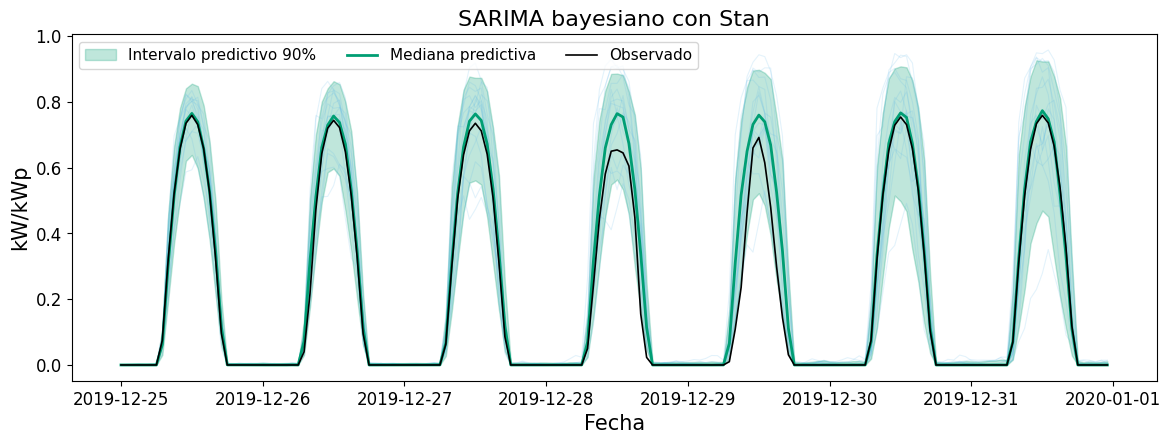

In [18]:
fig, ax = plt.subplots(figsize=(14, 4.5))
for path in scenarios[:15]:
    ax.plot(test_index, path, color="#56B4E9", alpha=.16, lw=.8)
ax.fill_between(test_index, q05, q95, color="#009E73", alpha=.25, label="Intervalo predictivo 90%")
ax.plot(test_index, median, color="#009E73", lw=2, label="Mediana predictiva")
ax.plot(test_index, observed, color="black", lw=1.2, label="Observado")
ax.set(title="SARIMA bayesiano con Stan", xlabel="Fecha", ylabel="kW/kWp")
ax.legend(ncol=3)
plt.show()


### Actividad 5: evaluación

In [19]:
# Completa las métricas:
#
# mae = ...
# rmse = ...
# coverage = ...


In [20]:
# Solución de referencia
mae = np.mean(np.abs(observed - median))
rmse = np.sqrt(np.mean((observed - median) ** 2))
coverage = np.mean((observed >= q05) & (observed <= q95))
print(f"MAE = {mae:.4f} | RMSE = {rmse:.4f} | Cobertura 90% = {coverage:.1%}")


MAE = 0.0216 | RMSE = 0.0516 | Cobertura 90% = 95.8%


## Guardar los cuantiles predictivos

In [21]:
results_dir = Path("resultados")
results_dir.mkdir(exist_ok=True)

forecast_table = pd.DataFrame({
    "fecha": test_index,
    "observado": observed,
    "q05": q05,
    "q50": median,
    "q95": q95,
})
forecast_file = results_dir / "forecast_sarima_bayesiano_stan.csv"
forecast_table.to_csv(forecast_file, index=False)
print(f"Predicciones guardadas en: {forecast_file}")
display(forecast_table.head())


Predicciones guardadas en: resultados/forecast_sarima_bayesiano_stan.csv


,fecha,observado,q05,q50,q95
0,2019-12-25 00:00:00,0.0,0.0,0.0,0.001768
1,2019-12-25 01:00:00,0.0,0.0,0.0,0.002600
2,2019-12-25 02:00:00,0.0,0.0,0.0,0.003250
3,2019-12-25 03:00:00,0.0,0.0,0.0,0.004121
4,2019-12-25 04:00:00,0.0,0.0,0.0,0.003314


## Conclusión

El modelo no cambió al pasar del notebook 03 a Stan:

\[
\text{máxima verosimilitud}
\quad\longrightarrow\quad
\text{distribución posterior}.
\]

Stan permite incorporar priors, cuantificar incertidumbre de parámetros y
simular trayectorias predictivas completas.
